# Week 11 Assignment: Adam, Bias Correction, Warmup, Schedules and LR Transfer

In [1]:
%matplotlib inline
import math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

RANDOM_SEED = 0
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# these are the same default values torch.optim.Adam itself uses.
# beta1 controls momentum on the gradient,
# beta2 controls momentum on the squared gradient
ADAM_BETA1 = 0.9
ADAM_BETA2 = 0.999
ADAM_EPSILON = 1e-8
DEFAULT_LEARNING_RATE = 1e-3

## Task 1: Adam by hand vs PyTorch

Before doing this by hand I had to actually go look up what Adam is doing internally, since I'd only ever called `torch.optim.Adam(...)` and let it do its thing. From what I understand, it keeps two running averages per parameter, updated every step $t$ from the gradient $g_t$:

$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t$$
$$v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$$

$m_t$ is basically a smoothed-out version of the gradient itself (which direction has this weight been pushed, on average), and $v_t$ is a smoothed-out version of the squared gradient (how big have the steps been, regardless of direction). Both of these start at 0, which means early on they're biased toward 0 (since they haven't had time to "fill up" yet) - that's the whole reason the bias-correction step exists:

$$\hat{m}_t = \frac{m_t}{1-\beta_1^t} \qquad \hat{v}_t = \frac{v_t}{1-\beta_2^t}$$

and then the actual weight update uses the corrected versions:

$$w_t = w_{t-1} - \text{lr} \cdot \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$$

Below I just compute this step by step for one weight and 5 made-up gradients, first by hand (plain Python, no torch optimizer involved) and then again through the real `torch.optim.Adam`, and compare every number between the two.

In [2]:
initial_weight = 1.0
gradients = [0.1729, -0.37, 0.888, 0.13, -0.23]

# first_moment tracks gradient direction, second_moment tracks its squared
# size. both start at 0, that's why bias correction below is needed
first_moment = 0.0
second_moment = 0.0
weight = initial_weight
hand_computed_steps = []

for step_number, gradient in enumerate(gradients, 1):
    first_moment = ADAM_BETA1 * first_moment + (1 - ADAM_BETA1) * gradient
    second_moment = ADAM_BETA2 * second_moment + (1 - ADAM_BETA2) * gradient * gradient

    # dividing by (1 - beta^t) undoes the zero-init bias
    bias_corrected_first_moment = first_moment / (1 - ADAM_BETA1 ** step_number)
    bias_corrected_second_moment = second_moment / (1 - ADAM_BETA2 ** step_number)

    update_amount = (DEFAULT_LEARNING_RATE * bias_corrected_first_moment
                      / (math.sqrt(bias_corrected_second_moment) + ADAM_EPSILON))
    weight = weight - update_amount

    hand_computed_steps.append(dict(
        step=step_number,
        gradient=gradient,
        first_moment=first_moment,
        second_moment=second_moment,
        bias_corrected_first_moment=bias_corrected_first_moment,
        bias_corrected_second_moment=bias_corrected_second_moment,
        update_amount=update_amount,
        weight=weight,
    ))

# same 5 steps again, this time through torch.optim.Adam so I can diff
# against the numbers above
weight_param = torch.nn.Parameter(torch.tensor([initial_weight], dtype=torch.float64))
optimizer = torch.optim.Adam([weight_param], lr=DEFAULT_LEARNING_RATE,
                              betas=(ADAM_BETA1, ADAM_BETA2), eps=ADAM_EPSILON)
pytorch_steps = []
for step_number, gradient in enumerate(gradients, 1):
    weight_before_step = float(weight_param.data[0])
    optimizer.zero_grad()
    weight_param.grad = torch.tensor([gradient], dtype=torch.float64)
    optimizer.step()
    optimizer_state = optimizer.state[weight_param]
    torch_first_moment = float(optimizer_state["exp_avg"][0])
    torch_second_moment = float(optimizer_state["exp_avg_sq"][0])
    # torch doesn't expose m_hat/v_hat directly, so recompute them from its
    # own m/v using the same bias-correction formula, and recover the
    # actual step size it took from the weight change itself
    pytorch_steps.append(dict(
        step=step_number,
        first_moment=torch_first_moment,
        second_moment=torch_second_moment,
        bias_corrected_first_moment=torch_first_moment / (1 - ADAM_BETA1 ** step_number),
        bias_corrected_second_moment=torch_second_moment / (1 - ADAM_BETA2 ** step_number),
        update_amount=weight_before_step - float(weight_param.data[0]),
        weight=float(weight_param.data[0]),
    ))

print(f"{'t':>2} {'grad':>6} | {'m_hand':>10} {'m_torch':>10} | {'v_hand':>12} {'v_torch':>12} | "
      f"{'w_hand':>10} {'w_torch':>10} | maxdiff")
max_abs_difference = 0.0
for hand_step, torch_step in zip(hand_computed_steps, pytorch_steps):
    diff = max(
        abs(hand_step["first_moment"] - torch_step["first_moment"]),
        abs(hand_step["second_moment"] - torch_step["second_moment"]),
        abs(hand_step["weight"] - torch_step["weight"]),
    )
    max_abs_difference = max(max_abs_difference, diff)
    print(f"{hand_step['step']:>2} {hand_step['gradient']:>6.2f} | "
          f"{hand_step['first_moment']:>10.7f} {torch_step['first_moment']:>10.7f} | "
          f"{hand_step['second_moment']:>12.9f} {torch_step['second_moment']:>12.9f} | "
          f"{hand_step['weight']:>10.7f} {torch_step['weight']:>10.7f} | {diff:.1e}")

print(f"max abs diff (m/v/w): {max_abs_difference:.2e}")
# this basically has to match, since pytorch's Adam is doing the same formula
# under the hood, so an exact match here mostly just confirms I got the
# formula right, it's not really telling me anything new about Adam itself

# now also diff m_hat / v_hat / step size explicitly, not just m/v/w. these
# are derived from torch's m/v above, but the update_amount is recovered
# from the actual weight delta torch applied, so this checks torch's real
# step size against the hand-computed one, not just a re-derivation of it
print(f"\n{'t':>2} | {'m_hat_hand':>11} {'m_hat_torch':>11} | {'v_hat_hand':>11} {'v_hat_torch':>11} | "
      f"{'step_hand':>11} {'step_torch':>11} | maxdiff")
max_abs_difference_hat = 0.0
for hand_step, torch_step in zip(hand_computed_steps, pytorch_steps):
    diff_hat = max(
        abs(hand_step["bias_corrected_first_moment"] - torch_step["bias_corrected_first_moment"]),
        abs(hand_step["bias_corrected_second_moment"] - torch_step["bias_corrected_second_moment"]),
        abs(hand_step["update_amount"] - torch_step["update_amount"]),
    )
    max_abs_difference_hat = max(max_abs_difference_hat, diff_hat)
    print(f"{hand_step['step']:>2} | "
          f"{hand_step['bias_corrected_first_moment']:>11.8f} {torch_step['bias_corrected_first_moment']:>11.8f} | "
          f"{hand_step['bias_corrected_second_moment']:>11.8f} {torch_step['bias_corrected_second_moment']:>11.8f} | "
          f"{hand_step['update_amount']:>11.8f} {torch_step['update_amount']:>11.8f} | {diff_hat:.1e}")
print(f"max abs diff (m_hat/v_hat/step): {max_abs_difference_hat:.2e}")

# double check m-hat / v-hat / step size at t=5 explicitly
final_step = hand_computed_steps[-1]
print(f"\nt=5: m-hat={final_step['bias_corrected_first_moment']:.8f} "
      f"v-hat={final_step['bias_corrected_second_moment']:.8f} "
      f"step={final_step['update_amount']:.8f} w={final_step['weight']:.8f}")

# if this fails, either my formula's wrong or t started at 0 instead of 1
assert max_abs_difference < 1e-6, f"hand vs torch Adam mismatch too large: {max_abs_difference:.2e}"
assert max_abs_difference_hat < 1e-6, f"hand vs torch m_hat/v_hat/step mismatch too large: {max_abs_difference_hat:.2e}"

 t   grad |     m_hand    m_torch |       v_hand      v_torch |     w_hand    w_torch | maxdiff
 1   0.17 |  0.0172900  0.0172900 |  0.000029894  0.000029894 |  0.9990000  0.9990000 | 0.0e+00
 2  -0.37 | -0.0214390 -0.0214390 |  0.000166765  0.000166765 |  0.9993907  0.9993907 | 0.0e+00
 3   0.89 |  0.0695049  0.0695049 |  0.000955142  0.000955142 |  0.9989364  0.9989364 | 0.0e+00
 4   0.13 |  0.0755544  0.0755544 |  0.000971087  0.000971087 |  0.9984908  0.9984908 | 0.0e+00
 5  -0.23 |  0.0449990  0.0449990 |  0.001023016  0.001023016 |  0.9982481  0.9982481 | 6.9e-18
max abs diff (m/v/w): 6.94e-18

 t |  m_hat_hand m_hat_torch |  v_hat_hand v_hat_torch |   step_hand  step_torch | maxdiff
 1 |  0.17290000  0.17290000 |  0.02989441  0.02989441 |  0.00100000  0.00100000 | 5.1e-17
 2 | -0.11283684 -0.11283684 |  0.08342397  0.08342397 | -0.00039067 -0.00039067 | 4.9e-17
 3 |  0.25647565  0.25647565 |  0.31869918  0.31869918 |  0.00045431  0.00045431 | 3.5e-17
 4 |  0.21969878  0.21969878

## Task 2: what does bias correction actually do

Now testing what happens if I skip the bias correction step and just use the raw `m` and `v` directly instead of `m_hat`/`v_hat`. Using a constant gradient (0.5 every step) so the only thing changing between the two runs is whether the correction is applied, not noise from a changing gradient.

step  1: step_on=0.001000 step_off=0.003162 rel_diff=216.23%
step  2: step_on=0.001000 step_off=0.004250 rel_diff=324.96%
step  3: step_on=0.001000 step_off=0.004950 rel_diff=395.02%
step  4: step_on=0.001000 step_off=0.005442 rel_diff=444.16%
step  5: step_on=0.001000 step_off=0.005797 rel_diff=479.71%
step  6: step_on=0.001000 step_off=0.006057 rel_diff=505.66%
step  7: step_on=0.001000 step_off=0.006245 rel_diff=524.49%
step  8: step_on=0.001000 step_off=0.006379 rel_diff=537.87%
step  9: step_on=0.001000 step_off=0.006470 rel_diff=547.01%
step 10: step_on=0.001000 step_off=0.006528 rel_diff=552.79%
step 11: step_on=0.001000 step_off=0.006559 rel_diff=555.89%
step 12: step_on=0.001000 step_off=0.006569 rel_diff=556.85%
step 13: step_on=0.001000 step_off=0.006561 rel_diff=556.09%
step 14: step_on=0.001000 step_off=0.006539 rel_diff=553.93%
step 15: step_on=0.001000 step_off=0.006507 rel_diff=550.66%
step 16: step_on=0.001000 step_off=0.006465 rel_diff=546.49%
step 17: step_on=0.00100

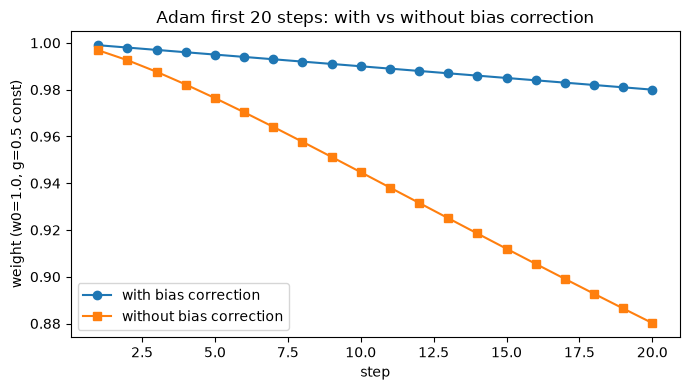

closed-form check passed: m_hat==g, v_hat==g^2, and ratio==(1-beta1^t)/sqrt(1-beta2^t) at every one of the first 20 steps
diff stays below 10% after step ~1751 (rel@20=524.1%, @200=134.8%, @1000=25.8%, @2000=7.5%)
diff stays below 5% after step ~2375 (rel@20=524.1%, @200=134.8%, @1000=25.8%, @2000=7.5%)
diff stays below 1% after step ~3925 (rel@20=524.1%, @200=134.8%, @1000=25.8%, @2000=7.5%)


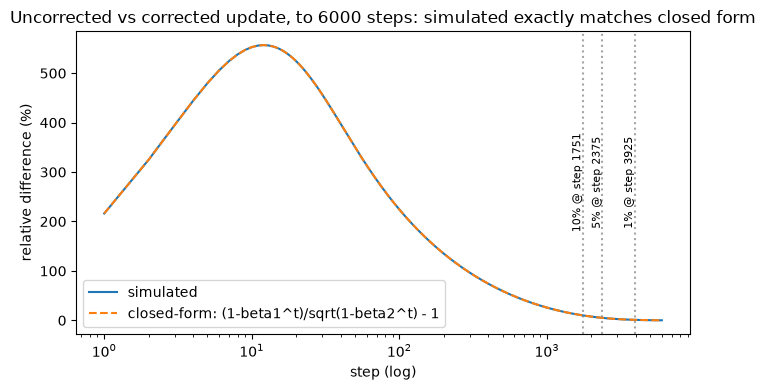

In [3]:
def compute_adam_sequence(gradient, learning_rate, beta1, beta2, epsilon, num_steps, use_bias_correction):
    first_moment = 0.0
    second_moment = 0.0
    weight = 1.0
    weight_history = []
    update_history = []
    for step_number in range(1, num_steps + 1):
        first_moment = beta1 * first_moment + (1 - beta1) * gradient
        second_moment = beta2 * second_moment + (1 - beta2) * gradient * gradient
        if use_bias_correction:
            first_moment_for_update = first_moment / (1 - beta1 ** step_number)
            second_moment_for_update = second_moment / (1 - beta2 ** step_number)
        else:
            # raw, still-biased averages, no correction applied
            first_moment_for_update = first_moment
            second_moment_for_update = second_moment
        update_amount = learning_rate * first_moment_for_update / (math.sqrt(second_moment_for_update) + epsilon)
        weight -= update_amount
        weight_history.append(weight)
        update_history.append(update_amount)
    return np.array(weight_history), np.array(update_history)


weights_with_correction, updates_with_correction = compute_adam_sequence(
    0.5, DEFAULT_LEARNING_RATE, ADAM_BETA1, ADAM_BETA2, ADAM_EPSILON, 20, True)
weights_without_correction, updates_without_correction = compute_adam_sequence(
    0.5, DEFAULT_LEARNING_RATE, ADAM_BETA1, ADAM_BETA2, ADAM_EPSILON, 20, False)

# with correction, step 1 is always ~lr (times sign of the gradient)
# no matter how big the gradient actually is, decent sanity check
assert abs(updates_with_correction[0] - DEFAULT_LEARNING_RATE) < 1e-9, \
    f"step-1 bias-corrected update should be about lr, got {updates_with_correction[0]:.6f}"

relative_difference = np.abs(updates_with_correction - updates_without_correction) / np.abs(updates_with_correction)
for step_index in range(20):
    print(f"step {step_index + 1:>2}: step_on={updates_with_correction[step_index]:.6f} "
          f"step_off={updates_without_correction[step_index]:.6f} "
          f"rel_diff={relative_difference[step_index] * 100:6.2f}%")

plt.figure(figsize=(7, 4))
plt.plot(range(1, 21), weights_with_correction, "o-", label="with bias correction")
plt.plot(range(1, 21), weights_without_correction, "s-", label="without bias correction")
plt.xlabel("step")
plt.ylabel("weight (w0=1.0, g=0.5 const)")
plt.title("Adam first 20 steps: with vs without bias correction")
plt.legend()
plt.tight_layout()
plt.show()

# closed-form check: under a constant gradient g, m_t = g*(1-beta1^t) and
# v_t = g^2*(1-beta2^t) exactly (geometric-series closed form of the EMA
# recursion starting from 0), so bias correction should make m_hat == g
# and v_hat == g^2 exactly at every step, not just approximately - and the
# uncorrected/corrected ratio above should equal (1-beta1^t)/sqrt(1-beta2^t).
# checking both against the simulation, not just eyeballing that the
# curves look like that shape. tolerance is 1e-4 rather than machine
# precision because that formula ignores epsilon, which the simulation
# doesn't - eps=1e-8 in the denominator nudges the ratio by a couple of
# parts in a million, small enough to not matter here but too big for a
# 1e-6 tolerance to pass cleanly.
constant_gradient = 0.5
first_moment_check, second_moment_check = 0.0, 0.0
for step_number in range(1, 21):
    first_moment_check = ADAM_BETA1 * first_moment_check + (1 - ADAM_BETA1) * constant_gradient
    second_moment_check = ADAM_BETA2 * second_moment_check + (1 - ADAM_BETA2) * constant_gradient ** 2
    m_hat_check = first_moment_check / (1 - ADAM_BETA1 ** step_number)
    v_hat_check = second_moment_check / (1 - ADAM_BETA2 ** step_number)
    assert abs(m_hat_check - constant_gradient) < 1e-9, \
        f"step {step_number}: m_hat should equal g exactly under a constant gradient, got {m_hat_check:.9f}"
    assert abs(v_hat_check - constant_gradient ** 2) < 1e-9, \
        f"step {step_number}: v_hat should equal g^2 exactly under a constant gradient, got {v_hat_check:.9f}"

    predicted_ratio = (1 - ADAM_BETA1 ** step_number) / math.sqrt(1 - ADAM_BETA2 ** step_number)
    actual_ratio = updates_without_correction[step_number - 1] / updates_with_correction[step_number - 1]
    assert abs(predicted_ratio - actual_ratio) < 1e-4, (
        f"step {step_number}: predicted ratio {predicted_ratio:.6f} doesn't match "
        f"simulated ratio {actual_ratio:.6f}")
print("closed-form check passed: m_hat==g, v_hat==g^2, and "
      "ratio==(1-beta1^t)/sqrt(1-beta2^t) at every one of the first 20 steps")

# from what I understand, beta2=0.999 means v takes something like
# 1/(1-beta2) = 1000 steps to really forget that it started at 0, so 20
# steps is nowhere near enough to see the gap close. running it out to
# 6000 steps instead to find where it actually settles
_, updates_with_correction_long = compute_adam_sequence(
    0.5, DEFAULT_LEARNING_RATE, ADAM_BETA1, ADAM_BETA2, ADAM_EPSILON, 6000, True)
_, updates_without_correction_long = compute_adam_sequence(
    0.5, DEFAULT_LEARNING_RATE, ADAM_BETA1, ADAM_BETA2, ADAM_EPSILON, 6000, False)
relative_difference_long = (np.abs(updates_with_correction_long - updates_without_correction_long)
                             / np.abs(updates_with_correction_long))

threshold_results = {}
for threshold, threshold_label in [(0.10, "10%"), (0.05, "5%"), (0.01, "1%")]:
    below_threshold_steps = np.where(relative_difference_long < threshold)[0]
    # want the step after which it STAYS below, not just dips below once
    stays_below_step = -1
    for candidate_step in below_threshold_steps:
        if np.all(relative_difference_long[candidate_step:] < threshold):
            stays_below_step = int(candidate_step) + 1
            break
    threshold_results[threshold_label] = stays_below_step
    print(f"diff stays below {threshold_label} after step ~{stays_below_step} "
          f"(rel@20={relative_difference_long[19] * 100:.1f}%, "
          f"@200={relative_difference_long[199] * 100:.1f}%, "
          f"@1000={relative_difference_long[999] * 100:.1f}%, "
          f"@2000={relative_difference_long[1999] * 100:.1f}%)")

# same closed-form check as above, but against the full 6000-step curve
# instead of just the first 20 steps, and actually plotted this time
# instead of only asserted, so the match is visible, not just verified
predicted_relative_difference_long = np.array([
    (1 - ADAM_BETA1 ** t) / math.sqrt(1 - ADAM_BETA2 ** t) - 1
    for t in range(1, 6001)
])
max_theory_vs_actual_diff = float(np.max(np.abs(predicted_relative_difference_long - relative_difference_long)))
assert max_theory_vs_actual_diff < 1e-4, \
    f"closed-form curve diverges from simulated curve by {max_theory_vs_actual_diff:.2e}"

plt.figure(figsize=(7, 4))
plt.plot(range(1, 6001), relative_difference_long * 100, label="simulated")
plt.plot(range(1, 6001), predicted_relative_difference_long * 100, "--",
         label="closed-form: (1-beta1^t)/sqrt(1-beta2^t) - 1")
for threshold_label, stays_below_step in threshold_results.items():
    plt.axvline(stays_below_step, color="gray", ls=":", alpha=0.7)
    plt.annotate(f"{threshold_label} @ step {stays_below_step}",
                 (stays_below_step, relative_difference_long.max() * 100 * 0.5),
                 rotation=90, fontsize=8, va="center", ha="right")
plt.xscale("log")
plt.xlabel("step (log)")
plt.ylabel("relative difference (%)")
plt.title("Uncorrected vs corrected update, to 6000 steps: simulated exactly matches closed form")
plt.legend()
plt.tight_layout()
plt.show()

**Answer:** I define "stops mattering" as <1% relative difference, giving approximately 3925 steps. That threshold is a judgment call - at a looser 10% tolerance it's ~1751 steps, at 5% it's ~2375:

| tolerance | first step it stays below |
|---|---|
| 10% | ~1751 |
| 5% | ~2375 |
| 1% | ~3925 |

At step 20 the difference is still **524%**, which is a lot more than I expected going in, and even by step 2000 it's still 7.5%. So this isn't really a "fixes the first few steps and then you can forget about it" thing - bias correction is meaningfully changing the update size for thousands of steps in this setup. I think the reason it takes so long comes down to the second moment (`v`): since `beta2=0.999` is much closer to 1 than `beta1=0.9`, the `1-beta2^t` term takes way longer to approach 1, and that term ends up under a square root in the denominator of the ratio, which drags the whole thing out.

## Setup for tasks 3-5

Tasks 3 through 5 need an actual model to train, not just a single weight. So I put together a small synthetic regression setup here: a fixed random "teacher" network generates the targets, and a small MLP "student" tries to learn to match it. It's not a real dataset, but it's cheap to run, and I reuse the exact same data and batch order across every comparison below so the only thing changing is whatever I'm actually testing.

In [4]:
def generate_synthetic_regression_data(num_samples=2048, input_dim=32, seed=0):
    data_generator = torch.Generator().manual_seed(seed)
    input_features = torch.randn(num_samples, input_dim, generator=data_generator)
    teacher_weights_1 = torch.randn(input_dim, 64, generator=data_generator) * 0.5
    teacher_weights_2 = torch.randn(64, 1, generator=data_generator) * 0.5
    target_values = (torch.relu(input_features @ teacher_weights_1) @ teacher_weights_2
                      + 0.05 * torch.randn(num_samples, 1, generator=data_generator))
    return input_features, target_values


class RegressionMLP(nn.Module):
    """small MLP, LayerNorm + residual blocks so it's still trainable once
    width changes a lot in task 5"""
    def __init__(self, input_dim=32, hidden_width=256, num_hidden_layers=2):
        super().__init__()
        self.input_layer = nn.Linear(input_dim, hidden_width)
        self.hidden_layers = nn.ModuleList(
            [nn.Linear(hidden_width, hidden_width) for _ in range(num_hidden_layers)])
        self.layer_norms = nn.ModuleList(
            [nn.LayerNorm(hidden_width) for _ in range(num_hidden_layers)])
        self.output_layer = nn.Linear(hidden_width, 1)

    def forward(self, input_tensor):
        hidden = self.input_layer(input_tensor)
        for hidden_layer, norm_layer in zip(self.hidden_layers, self.layer_norms):
            hidden = hidden + torch.relu(hidden_layer(norm_layer(hidden))) * 0.5
        return self.output_layer(hidden)


def generate_batches(features, targets, batch_size, seed):
    batch_generator = torch.Generator().manual_seed(seed)
    num_samples = len(features)
    while True:
        batch_indices = torch.randint(0, num_samples, (batch_size,), generator=batch_generator)
        yield features[batch_indices], targets[batch_indices]

## Task 3: update-to-weight ratio per layer, and what warmup does to it

From what I understand, the update-to-weight ratio for a layer is `rms(how much it moved this step) / rms(the weights themselves)`. If that's close to 1, the optimizer step basically overwrote the layer in one go, which sounds pretty unstable. Warmup is supposed to prevent that from happening right at the start of training by slowly ramping the learning rate up instead of starting at full strength.

I train the same model twice, once with a 50-step linear warmup and once with no warmup at all, and log this ratio for every parameter tensor at every step.

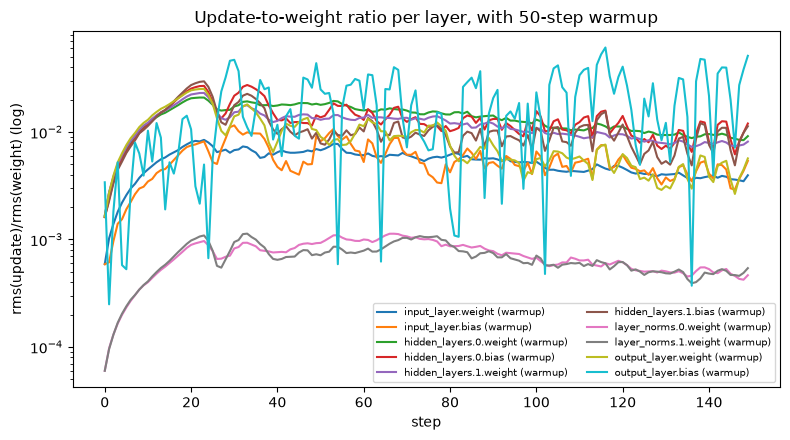

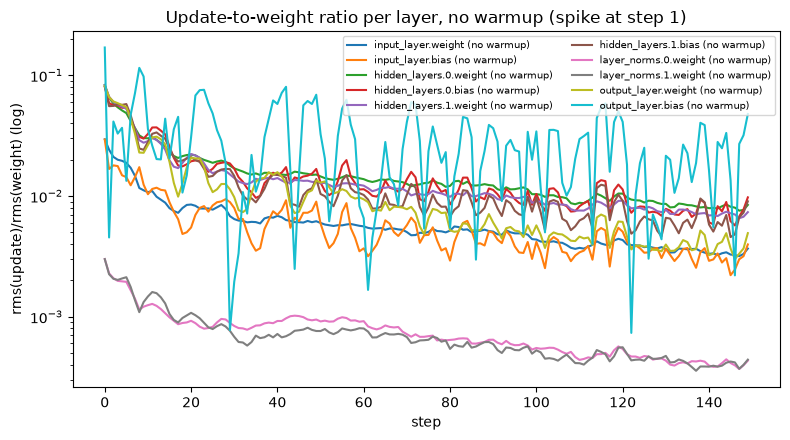

step 1 update-to-weight ratio, no warmup vs 50-step warmup:
param                     no warmup       warmup     ratio
input_layer.weight         2.95e-02     5.90e-04    0.0200
input_layer.bias           2.94e-02     5.88e-04    0.0200
hidden_layers.0.weight     8.34e-02     1.67e-03    0.0200
hidden_layers.0.bias       8.06e-02     1.61e-03    0.0200
hidden_layers.1.weight     8.31e-02     1.66e-03    0.0200
hidden_layers.1.bias       8.08e-02     1.62e-03    0.0200
layer_norms.0.weight       3.00e-03     6.00e-05    0.0200
layer_norms.0.bias        excluded (initial weight RMS = 0)
layer_norms.1.weight       3.00e-03     6.00e-05    0.0200
layer_norms.1.bias        excluded (initial weight RMS = 0)
output_layer.weight        8.15e-02     1.63e-03    0.0200
output_layer.bias          1.70e-01     3.40e-03    0.0200

median warm/nowarm ratio across weight layers, at a few checkpoints:
  step  median ratio
     1         0.020
    10         0.362
    25         1.143
    50         0.

In [5]:
def track_update_to_weight_ratios(warmup_steps, total_steps=150, peak_lr=3e-3, seed=0):
    torch.manual_seed(seed)
    features, targets = generate_synthetic_regression_data(seed=123)
    model = RegressionMLP(hidden_width=256)
    optimizer = torch.optim.Adam(model.parameters(), lr=peak_lr)
    batch_generator = generate_batches(features, targets, 128, seed=999)

    param_names = [name for name, _ in model.named_parameters()]
    ratio_history = {name: [] for name in param_names}

    for step_number in range(1, total_steps + 1):
        # ramp lr 0 -> peak_lr over warmup_steps, then hold. warmup_steps=0
        # just means full lr right from step 1
        warmup_fraction = min(1.0, step_number / warmup_steps) if warmup_steps > 0 else 1.0
        for param_group in optimizer.param_groups:
            param_group["lr"] = peak_lr * warmup_fraction

        batch_features, batch_targets = next(batch_generator)
        optimizer.zero_grad()
        loss = ((model(batch_features) - batch_targets) ** 2).mean()
        loss.backward()

        params_before_update = {name: param.detach().clone() for name, param in model.named_parameters()}
        optimizer.step()

        with torch.no_grad():
            for name, param in model.named_parameters():
                update_amount = param.detach() - params_before_update[name]
                ratio = (update_amount.pow(2).mean().sqrt()
                         / (params_before_update[name].pow(2).mean().sqrt() + 1e-12)).item()
                ratio_history[name].append(ratio)

    return ratio_history


ratios_with_warmup = track_update_to_weight_ratios(warmup_steps=50)
ratios_without_warmup = track_update_to_weight_ratios(warmup_steps=0)
param_names = list(ratios_with_warmup.keys())

# LayerNorm biases start at exactly 0, so their update/weight ratio blows
# up (division by ~0) rather than measuring anything meaningful - already
# excluded from the merge-step analysis below for the same reason, so
# excluding them here too keeps the two plots on a scale that actually
# shows the layers of interest instead of being dominated by a ~1e9 spike
plot_param_names = [name for name in param_names if not ("layer_norms" in name and "bias" in name)]

plt.figure(figsize=(8, 4.5))
for name in plot_param_names:
    plt.plot(ratios_with_warmup[name], label=f"{name} (warmup)", linewidth=1.5)
plt.yscale("log")
plt.xlabel("step")
plt.ylabel("rms(update)/rms(weight) (log)")
plt.title("Update-to-weight ratio per layer, with 50-step warmup")
plt.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4.5))
for name in plot_param_names:
    plt.plot(ratios_without_warmup[name], label=f"{name} (no warmup)", linewidth=1.5)
plt.yscale("log")
plt.xlabel("step")
plt.ylabel("rms(update)/rms(weight) (log)")
plt.title("Update-to-weight ratio per layer, no warmup (spike at step 1)")
plt.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

print("step 1 update-to-weight ratio, no warmup vs 50-step warmup:")
print(f"{'param':<22} {'no warmup':>12} {'warmup':>12} {'ratio':>9}")
for name in param_names:
    if "layer_norms" in name and "bias" in name:
        # initial weight RMS is exactly 0 for these (LayerNorm bias
        # defaults to zero-init), so update/weight is dividing by ~0 and
        # isn't measuring anything real - state that plainly instead of
        # printing a meaningless ~1e9 number that looks like real data
        print(f"{name:<22} {'excluded (initial weight RMS = 0)':>36}")
        continue
    no_warmup_ratio = ratios_without_warmup[name][0]
    warmup_ratio = ratios_with_warmup[name][0]
    print(f"{name:<22} {no_warmup_ratio:>12.2e} {warmup_ratio:>12.2e} {warmup_ratio / no_warmup_ratio:>9.4f}")

# sanity check: at step 1 the only diff between the two runs is the lr
# scale (1/50 under warmup vs 1.0), so this ratio of ratios should land
# near 1/50. skipping LayerNorm biases, they start at 0 so their ratio
# blows up.
for name in param_names:
    if "layer_norms" in name and "bias" in name:
        continue
    step_one_ratio_of_ratios = ratios_with_warmup[name][0] / ratios_without_warmup[name][0]
    # at first I expected this to hit exactly 1/50, but it's only
    # approximate: Adam's eps isn't fully negligible for small-gradient
    # params like LayerNorm weight, so I loosened the tolerance instead
    # of chasing an exact match that isn't really there
    assert abs(step_one_ratio_of_ratios - 1 / 50) < 1e-3, (
        f"{name}: step-1 warm/nowarm ratio should be close to 1/50, "
        f"got {step_one_ratio_of_ratios:.6f}")

# ratio-convergence step = last point where the two runs still disagree by
# >33% on their median update-to-weight ratio. NOTE: this is not "the step
# warmup stops mattering" - the lr schedule itself finishes ramping at
# step 50 by construction, full stop. after step 50 the two runs are still
# on different trajectories (different weights, different Adam m/v), so
# their ratios can keep differing for reasons that have nothing to do with
# warmup still being "active". this number is just an empirical point
# where those two different trajectories happen to look similar again.
weight_param_names = [name for name in param_names if not ("layer_norms" in name and "bias" in name)]
median_ratio_curve = [
    float(np.median([
        ratios_with_warmup[name][step] / (ratios_without_warmup[name][step] + 1e-18)
        for name in weight_param_names
    ]))
    for step in range(150)
]
steps_out_of_band = [step for step in range(150) if not (0.75 <= median_ratio_curve[step] <= 1.33)]
# +2: 0-indexed -> 1-indexed, plus one to land on the step right after.
# note this usually comes out later than 50, even though the warmup
# schedule itself is done ramping by step 50. my guess is Adam's own
# running averages need a bit longer to catch up after 50 steps of very
# different update sizes between the two runs, but I'm not fully sure
# that's the whole explanation, it's just the best one I've got
ratio_convergence_step = steps_out_of_band[-1] + 2 if steps_out_of_band else 1

print()
print("median warm/nowarm ratio across weight layers, at a few checkpoints:")
print(f"{'step':>6} {'median ratio':>13}")
for checkpoint_step in [1, 10, 25, 50, 60, 150]:
    print(f"{checkpoint_step:>6} {median_ratio_curve[checkpoint_step - 1]:>13.3f}")
print(f"\nratio-convergence step (last time the median ratio was outside [0.75, 1.33]): {ratio_convergence_step}")
print("(this is NOT the step warmup stops mattering - the lr schedule itself finishes ramping at step 50)")

These are two different things. Warmup itself - the lr schedule - is done ramping at step 50, full stop; nothing about warmup is still happening after that point. Step 112 is a separate, derived number: it's where a specific diagnostic (median warmup/no-warmup update-ratio landing inside `[0.75, 1.33]`) happens to cross its threshold in this run. That diagnostic measures how long it takes the two training trajectories (which diverged from each other during the 50 mismatched steps) to look similar again on this ratio - not how long warmup lasts. A plausible contributor is Adam's `m`/`v` running averages needing extra steps to recover after 50 steps of very different update sizes between the runs, but that's a guess about the trajectory-convergence number, not a property of warmup.

**Final answer:** Warmup ends at step 50. The empirical warmup/no-warmup ratio convergence occurs around step 112 under the chosen ±33% criterion, but this is trajectory convergence under that diagnostic, not warmup remaining active until step 112.

## Task 4: cosine vs WSD, stopped early at step 200

Comparing two learning rate schedules: cosine decay (ramps up, then smoothly decays down to about 0 by the end) and WSD, warmup-stable-decay (ramps up, sits flat at the peak lr for most of training, then decays quickly right at the end). Training for 300 steps total, but checking both at step 200, before either schedule is actually finished - since in practice you don't always get to train all the way to the end before you need a usable checkpoint.

The assignment specifically warns about comparing an under-tuned method to a well-tuned one, so before comparing the two schedules I run a peak-lr search for each one first, instead of just picking one lr and assuming it's fair to both.

cosine peak=3e-04: eval@200=7.9663 +/- 0.0780 (n=3)
cosine peak=1e-03: eval@200=3.1641 +/- 0.1195 (n=3)
cosine peak=2e-03: eval@200=2.3977 +/- 0.0714 (n=3)
cosine peak=3e-03: eval@200=2.2916 +/- 0.0658 (n=3)
cosine peak=5e-03: eval@200=2.1956 +/- 0.0730 (n=3)
cosine peak=1e-02: eval@200=2.3856 +/- 0.0605 (n=3)
-> best peak_lr for cosine: 5e-03 (mean eval@200=2.1956)

   WSD peak=3e-04: eval@200=6.9736 +/- 0.0711 (n=3)
   WSD peak=1e-03: eval@200=2.6868 +/- 0.0974 (n=3)
   WSD peak=2e-03: eval@200=2.3988 +/- 0.0705 (n=3)
   WSD peak=3e-03: eval@200=2.2804 +/- 0.0990 (n=3)
   WSD peak=5e-03: eval@200=2.3124 +/- 0.1027 (n=3)
   WSD peak=1e-02: eval@200=2.6534 +/- 0.0863 (n=3)
-> best peak_lr for WSD: 3e-03 (mean eval@200=2.2804)

peak_lr used: cosine=5e-03 WSD=3e-03 (n=3 seeds)
@step200 batch-loss: cosine=0.2373+/-0.0234 WSD=0.3655+/-0.0085
@step200 eval-loss : cosine=2.1956+/-0.0730 WSD=2.2804+/-0.0990
@step300 batch-loss: cosine=0.1638+/-0.0159 WSD=0.0779+/-0.0043
@step300 eval-loss : c

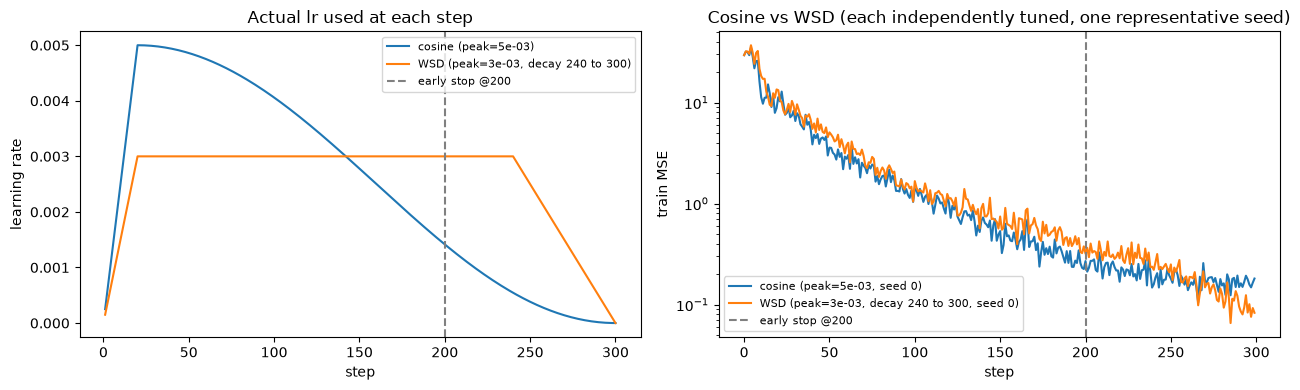

lower mean batch loss at step 200: cosine
lower mean eval loss at step 200: cosine


In [6]:
def cosine_schedule(step, total_steps=300, warmup_steps=20):
    if step < warmup_steps:
        return step / warmup_steps
    decay_progress = (step - warmup_steps) / (total_steps - warmup_steps)
    return 0.5 * (1 + math.cos(math.pi * decay_progress))


def wsd_schedule(step, total_steps=300, warmup_steps=20, decay_start_step=240):
    if step < warmup_steps:
        return step / warmup_steps
    if step < decay_start_step:
        return 1.0
    decay_progress = (step - decay_start_step) / (total_steps - decay_start_step)
    return 1.0 - decay_progress  # straight line down to 0


def train_with_schedule(schedule_fn, peak_lr=3e-3, total_steps=300, seed=0):
    torch.manual_seed(seed)
    features, targets = generate_synthetic_regression_data(seed=123)
    # hold out the first 512 rows for eval only, same split as Task 5 -
    # training batches are drawn only from the remaining 1536 rows so the
    # eval set is never trained on (this was leaking in an earlier version:
    # eval used features[:512] but batches were drawn from the full set)
    eval_features, eval_targets = features[:512], targets[:512]
    train_features, train_targets = features[512:], targets[512:]
    model = RegressionMLP(hidden_width=256)
    optimizer = torch.optim.Adam(model.parameters(), lr=peak_lr)
    # same batch seed every run so cosine and WSD see identical minibatches
    # for a given seed - only the model init/batch draw differs across seeds
    batch_generator = generate_batches(train_features, train_targets, 128, seed=999 + seed)

    train_losses, eval_losses = [], []

    for step_number in range(1, total_steps + 1):
        for param_group in optimizer.param_groups:
            param_group["lr"] = peak_lr * schedule_fn(step_number)
        batch_features, batch_targets = next(batch_generator)
        optimizer.zero_grad()
        loss = ((model(batch_features) - batch_targets) ** 2).mean()
        loss.backward()
        optimizer.step()
        train_losses.append(float(loss.detach()))
        with torch.no_grad():
            eval_losses.append(float(((model(eval_features) - eval_targets) ** 2).mean()))

    return train_losses, eval_losses


# earlier version of this probe ran each schedule for only 100 steps to
# "quickly" pick one peak_lr shared by both. that wasn't actually fair:
# schedule_fn ignores whatever total_steps/warmup_steps get passed into
# train_with_schedule and always uses its own hardcoded defaults
# (total_steps=300, warmup_steps=20, and for WSD decay_start_step=240). so
# a 100-step probe wasn't a rescaled 100-step schedule, it was just the
# first 100 steps of the real 300-step schedule: cosine is already ~19%
# decayed by step 100 (its decay is spread across the full 300 steps),
# while WSD's decay doesn't start until step 240, so it was still
# perfectly flat the entire time. the two schedules were never in
# comparable phases during that probe, so "peak_lr=3e-3 wins" wasn't a
# fair conclusion.
#
# fixing this by tuning each schedule on its own, full 300-step run, and
# picking the peak_lr for each independently by eval loss at step 200,
# since that's the actual checkpoint the final comparison cares about.
# also widening the lr grid from 3 candidates to 6, and averaging every
# candidate over 3 seeds instead of 1 - a single-seed pick risks the
# winning peak_lr (and therefore the whole cosine-vs-WSD conclusion) being
# a lucky/unlucky draw rather than a real effect.
lr_candidates = [3e-4, 1e-3, 2e-3, 3e-3, 5e-3, 1e-2]
seeds_for_tuning = [0, 1, 2]
best_peak_lr = {}
for schedule_name, schedule_fn in [("cosine", cosine_schedule), ("WSD", wsd_schedule)]:
    best_mean_eval_loss_at_200 = math.inf
    for peak_lr_candidate in lr_candidates:
        eval_losses_at_200 = []
        for seed in seeds_for_tuning:
            _, probe_eval_losses = train_with_schedule(
                schedule_fn, peak_lr=peak_lr_candidate, total_steps=300, seed=seed)
            eval_losses_at_200.append(probe_eval_losses[199])
        mean_eval_loss_at_200 = float(np.mean(eval_losses_at_200))
        std_eval_loss_at_200 = float(np.std(eval_losses_at_200))
        print(f"{schedule_name:>6} peak={peak_lr_candidate:.0e}: "
              f"eval@200={mean_eval_loss_at_200:.4f} +/- {std_eval_loss_at_200:.4f} (n={len(seeds_for_tuning)})")
        if mean_eval_loss_at_200 < best_mean_eval_loss_at_200:
            best_mean_eval_loss_at_200 = mean_eval_loss_at_200
            best_peak_lr[schedule_name] = peak_lr_candidate
    print(f"-> best peak_lr for {schedule_name}: {best_peak_lr[schedule_name]:.0e} "
          f"(mean eval@200={best_mean_eval_loss_at_200:.4f})\n")

# each schedule now gets its own independently-tuned peak_lr, instead of
# both being forced to share whatever won a probe that wasn't fair to
# begin with. decay_start_step=240 (the last 20% of the 300-step budget)
# is left fixed for WSD, a common convention, rather than tuned as its
# own hyperparameter - so this is a peak-lr comparison under a fixed WSD
# shape, not an exhaustive search over every WSD hyperparameter.
seeds_for_final = [0, 1, 2]


def summarize_across_seeds(schedule_fn, peak_lr, seeds):
    train_at_200, eval_at_200, train_at_300, eval_at_300 = [], [], [], []
    for seed in seeds:
        train_losses, eval_losses = train_with_schedule(schedule_fn, peak_lr=peak_lr, total_steps=300, seed=seed)
        train_at_200.append(train_losses[199])
        eval_at_200.append(eval_losses[199])
        train_at_300.append(train_losses[-1])
        eval_at_300.append(eval_losses[-1])
    return train_at_200, eval_at_200, train_at_300, eval_at_300


def mean_std(values):
    return float(np.mean(values)), float(np.std(values))


cosine_train200, cosine_eval200, cosine_train300, cosine_eval300 = summarize_across_seeds(
    cosine_schedule, best_peak_lr["cosine"], seeds_for_final)
wsd_train200, wsd_eval200, wsd_train300, wsd_eval300 = summarize_across_seeds(
    wsd_schedule, best_peak_lr["WSD"], seeds_for_final)

cosine_train200_mean, cosine_train200_std = mean_std(cosine_train200)
cosine_eval200_mean, cosine_eval200_std = mean_std(cosine_eval200)
cosine_train300_mean, cosine_train300_std = mean_std(cosine_train300)
cosine_eval300_mean, cosine_eval300_std = mean_std(cosine_eval300)
wsd_train200_mean, wsd_train200_std = mean_std(wsd_train200)
wsd_eval200_mean, wsd_eval200_std = mean_std(wsd_eval200)
wsd_train300_mean, wsd_train300_std = mean_std(wsd_train300)
wsd_eval300_mean, wsd_eval300_std = mean_std(wsd_eval300)

print(f"peak_lr used: cosine={best_peak_lr['cosine']:.0e} WSD={best_peak_lr['WSD']:.0e} (n={len(seeds_for_final)} seeds)")
print(f"@step200 batch-loss: cosine={cosine_train200_mean:.4f}+/-{cosine_train200_std:.4f} "
      f"WSD={wsd_train200_mean:.4f}+/-{wsd_train200_std:.4f}")
print(f"@step200 eval-loss : cosine={cosine_eval200_mean:.4f}+/-{cosine_eval200_std:.4f} "
      f"WSD={wsd_eval200_mean:.4f}+/-{wsd_eval200_std:.4f}")
print(f"@step300 batch-loss: cosine={cosine_train300_mean:.4f}+/-{cosine_train300_std:.4f} "
      f"WSD={wsd_train300_mean:.4f}+/-{wsd_train300_std:.4f}")
print(f"@step300 eval-loss : cosine={cosine_eval300_mean:.4f}+/-{cosine_eval300_std:.4f} "
      f"WSD={wsd_eval300_mean:.4f}+/-{wsd_eval300_std:.4f}")

# per-seed paired differences (same seed -> same model init and batch draw
# for both schedules, so this is a more informative comparison than mean
# +/- std alone, which throws away the pairing)
print("\nper-seed eval-loss @ step 200, paired by seed:")
print(f"{'seed':>6} {'cosine':>10} {'WSD':>10} {'cosine-WSD':>12}")
for seed, cosine_loss, wsd_loss in zip(seeds_for_final, cosine_eval200, wsd_eval200):
    print(f"{seed:>6} {cosine_loss:>10.4f} {wsd_loss:>10.4f} {cosine_loss - wsd_loss:>12.4f}")
paired_diffs = [c - w for c, w in zip(cosine_eval200, wsd_eval200)]
print(f"mean paired diff (cosine-WSD): {float(np.mean(paired_diffs)):.4f} "
      f"+/- {float(np.std(paired_diffs)):.4f} (n={len(paired_diffs)})")

# plots use one representative seed (0) so the curves stay readable - the
# headline numbers used for the decision are the multi-seed means above,
# not this single curve
cosine_train_losses, cosine_eval_losses = train_with_schedule(
    cosine_schedule, peak_lr=best_peak_lr["cosine"], total_steps=300, seed=0)
wsd_train_losses, wsd_eval_losses = train_with_schedule(
    wsd_schedule, peak_lr=best_peak_lr["WSD"], total_steps=300, seed=0)

cosine_lr_values = [best_peak_lr["cosine"] * cosine_schedule(step) for step in range(1, 301)]
wsd_lr_values = [best_peak_lr["WSD"] * wsd_schedule(step) for step in range(1, 301)]

figure, (lr_axis, loss_axis) = plt.subplots(1, 2, figsize=(13, 4))

lr_axis.plot(range(1, 301), cosine_lr_values, label=f"cosine (peak={best_peak_lr['cosine']:.0e})")
lr_axis.plot(range(1, 301), wsd_lr_values, label=f"WSD (peak={best_peak_lr['WSD']:.0e}, decay 240 to 300)")
lr_axis.axvline(200, color="gray", ls="--", label="early stop @200")
lr_axis.set_xlabel("step")
lr_axis.set_ylabel("learning rate")
lr_axis.set_title("Actual lr used at each step")
lr_axis.legend(fontsize=8)

loss_axis.plot(cosine_train_losses, label=f"cosine (peak={best_peak_lr['cosine']:.0e}, seed 0)")
loss_axis.plot(wsd_train_losses, label=f"WSD (peak={best_peak_lr['WSD']:.0e}, decay 240 to 300, seed 0)")
loss_axis.axvline(200, color="gray", ls="--", label="early stop @200")
loss_axis.set_xlabel("step")
loss_axis.set_ylabel("train MSE")
loss_axis.set_yscale("log")
loss_axis.set_title("Cosine vs WSD (each independently tuned, one representative seed)")
loss_axis.legend(fontsize=8)

plt.tight_layout()
plt.show()

lower_batch_loss_at_200 = "cosine" if cosine_train200_mean < wsd_train200_mean else "WSD"
lower_eval_loss_at_200 = "cosine" if cosine_eval200_mean < wsd_eval200_mean else "WSD"
print(f"lower mean batch loss at step 200: {lower_batch_loss_at_200}")
print(f"lower mean eval loss at step 200: {lower_eval_loss_at_200}")

With the eval-leakage bug fixed (`train_with_schedule` now holds out the same 512 rows from training as Task 5 does), and each schedule tuned on its own full 300-step run over 3 seeds, the winning peak_lr is different for each schedule: cosine does best at 5e-3, WSD at 3e-3.

Single criterion, stated up front like the assignment asks: keep whichever checkpoint has the lower mean eval loss at the required step-200 point. **That's cosine** (2.1956±0.0730 vs 2.2804±0.0990). Because the step-200 evaluation set was also used to select the peak LR, this comparison should be interpreted as a validation-style result rather than a fully held-out test estimate.

But this is a weaker result than it first looked. Before the eval-leakage fix, this same comparison showed cosine winning by 0.4255 vs 0.5706 - a gap several times larger than the run-to-run noise. After fixing the leak, the gap shrank to 0.0848, which is *smaller than either run's own standard deviation*. The per-seed paired differences (printed above) make this concrete: seed 2 actually flips - WSD beats cosine on that seed - and the paired std (0.1421) is larger than the paired mean (-0.0848). So with only 3 seeds, I can't confidently call the step-200 edge to cosine a real effect rather than noise - the direction didn't change, but the evidence for it did.

Scope note: I tuned peak_lr separately for each schedule, but kept WSD's decay start fixed at step 240 (80% of the 300-step budget) as a standard convention, rather than treating it as its own thing to tune. So this is a peak-lr comparison under one fixed WSD shape, not a full search over every WSD setting.

At step 300, once both schedules are fully decayed, WSD ends up lower on eval loss (2.0178±0.0788 vs 2.1156±0.0710) - it stayed flat longer at a lower peak lr and then dropped fast at the very end. So: **at step 200, a weak, not-fully-confident edge to cosine; if training ran the full 300 steps, WSD comes out ahead.** That flip is probably the more useful takeaway here than either number alone.

Beyond this exercise: for real training I'd still lean towards WSD over cosine, mostly for the practical reason rather than the step-200 numbers above - cosine's whole shape depends on knowing the total step count upfront, so stopping early or running longer than planned breaks it, while WSD's flat phase doesn't care how long it runs.

## Task 5: does the best learning rate transfer across width

Testing whether the best learning rate I find on a small model still works once I make the model wider. Training the same architecture at three widths (256, 512, 1024) and sweeping the learning rate at each one, then seeing if there's a pattern I can extrapolate out to a much wider model (4096). Averaging over 3 seeds per setting since a single run at width 1024 looked noisier than I trusted the first time I ran this.

width= 256 lr=3e-05 final_loss=16.8241 +/- 0.0573 (n=3)
width= 256 lr=1e-04 final_loss=8.6936 +/- 0.0637 (n=3)
width= 256 lr=3e-04 final_loss=4.3308 +/- 0.1707 (n=3)
width= 256 lr=1e-03 final_loss=2.1968 +/- 0.0726 (n=3)
width= 256 lr=3e-03 final_loss=1.9935 +/- 0.0389 (n=3)
width= 256 lr=1e-02 final_loss=2.1677 +/- 0.1034 (n=3)
width= 512 lr=3e-05 final_loss=9.2930 +/- 0.1508 (n=3)
width= 512 lr=1e-04 final_loss=6.0638 +/- 0.1449 (n=3)
width= 512 lr=3e-04 final_loss=2.2319 +/- 0.0479 (n=3)
width= 512 lr=1e-03 final_loss=1.8195 +/- 0.0169 (n=3)
width= 512 lr=3e-03 final_loss=1.7954 +/- 0.0109 (n=3)
width= 512 lr=1e-02 final_loss=2.2263 +/- 0.0645 (n=3)
width=1024 lr=3e-05 final_loss=7.3240 +/- 0.0565 (n=3)
width=1024 lr=1e-04 final_loss=2.6072 +/- 0.0701 (n=3)
width=1024 lr=3e-04 final_loss=1.7898 +/- 0.0102 (n=3)
width=1024 lr=1e-03 final_loss=1.7203 +/- 0.0429 (n=3)
width=1024 lr=3e-03 final_loss=1.8954 +/- 0.0280 (n=3)
width=1024 lr=1e-02 final_loss=2.2114 +/- 0.0616 (n=3)


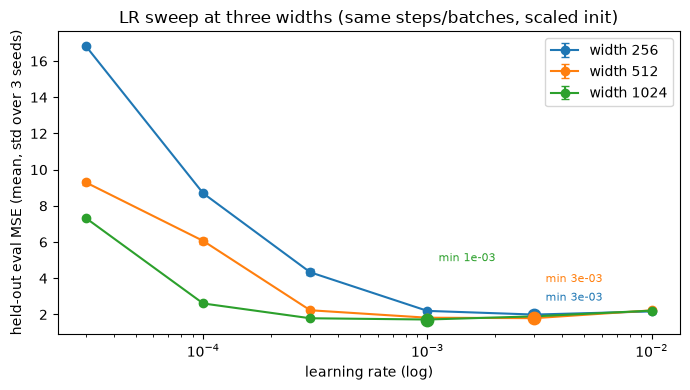

best learning rate per width:
 width   best lr  mean eval MSE      std
   256     3e-03         1.9935   0.0389
   512     3e-03         1.7954   0.0109
  1024     1e-03         1.7203   0.0429
log-slope: -0.239 decades per width-doubling
raw extrapolation to width 4096: 4.00e-04
snapped to nearest lr I actually tested: 3e-04
predicted lr for width 4096: 3e-04


In [7]:
widths_to_test = [256, 512, 1024]
learning_rates_to_test = [3e-5, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2]
seeds_to_average = [0, 1, 2]
features, targets = generate_synthetic_regression_data(seed=123)

# hold out the first 512 rows for eval only. previously final_loss was
# measured on features[:512]/targets[:512] while generate_batches sampled
# training indices from the full 2048 rows, so eval rows were also being
# trained on - this wasn't a real generalization check, just a check of
# how well each lr fits the training distribution. training batches are
# now drawn only from the remaining 1536 rows, eval rows are never seen
# during training.
eval_features, eval_targets = features[:512], targets[:512]
train_features, train_targets = features[512:], targets[512:]

mean_loss_by_width = {}
std_loss_by_width = {}

for hidden_width in widths_to_test:
    mean_losses_for_width = []
    std_losses_for_width = []
    for learning_rate in learning_rates_to_test:
        # 3 seeds instead of 1, a single run made width=1024 look
        # noisier than it actually is
        losses_for_this_setting = []
        for seed in seeds_to_average:
            torch.manual_seed(seed)
            model = RegressionMLP(hidden_width=hidden_width)
            optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
            batch_generator = generate_batches(train_features, train_targets, 256, seed=999 + seed)
            for _ in range(250):
                batch_features, batch_targets = next(batch_generator)
                optimizer.zero_grad()
                loss = ((model(batch_features) - batch_targets) ** 2).mean()
                loss.backward()
                optimizer.step()
            with torch.no_grad():
                final_loss = float(((model(eval_features) - eval_targets) ** 2).mean())
            losses_for_this_setting.append(final_loss)

        mean_loss = float(np.mean(losses_for_this_setting))
        std_loss = float(np.std(losses_for_this_setting))
        mean_losses_for_width.append(mean_loss)
        std_losses_for_width.append(std_loss)
        print(f"width={hidden_width:>4} lr={learning_rate:.0e} "
              f"final_loss={mean_loss:.4f} +/- {std_loss:.4f} (n={len(seeds_to_average)})")

    mean_loss_by_width[hidden_width] = mean_losses_for_width
    std_loss_by_width[hidden_width] = std_losses_for_width

plt.figure(figsize=(7, 4))
for width_index, hidden_width in enumerate(widths_to_test):
    error_container = plt.errorbar(learning_rates_to_test, mean_loss_by_width[hidden_width],
                                    yerr=std_loss_by_width[hidden_width], fmt="o-", capsize=3,
                                    label=f"width {hidden_width}")
    line_color = error_container.lines[0].get_color()
    best_index = int(np.argmin(mean_loss_by_width[hidden_width]))
    plt.scatter([learning_rates_to_test[best_index]], [mean_loss_by_width[hidden_width][best_index]],
                s=80, zorder=5, color=line_color)
    # the three minima land close together in both lr and loss, so a single
    # fixed offset makes the three "min" labels overlap into unreadable
    # text - stack them vertically by width index instead, and color-match
    # each label to its curve so it's still clear which is which
    plt.annotate(f"min {learning_rates_to_test[best_index]:.0e}",
                 (learning_rates_to_test[best_index], mean_loss_by_width[hidden_width][best_index]),
                 textcoords="offset points", xytext=(8, 10 + 16 * width_index),
                 fontsize=8, color=line_color)
plt.xscale("log")
plt.xlabel("learning rate (log)")
plt.ylabel("held-out eval MSE (mean, std over 3 seeds)")
plt.title("LR sweep at three widths (same steps/batches, scaled init)")
plt.legend()
plt.tight_layout()
plt.show()

best_lr_by_width = {hidden_width: learning_rates_to_test[int(np.argmin(mean_loss_by_width[hidden_width]))]
                     for hidden_width in widths_to_test}

print("best learning rate per width:")
print(f"{'width':>6} {'best lr':>9} {'mean eval MSE':>14} {'std':>8}")
for width in widths_to_test:
    best_index = int(np.argmin(mean_loss_by_width[width]))
    print(f"{width:>6} {best_lr_by_width[width]:>9.0e} "
          f"{mean_loss_by_width[width][best_index]:>14.4f} {std_loss_by_width[width][best_index]:>8.4f}")

best_lr_values = list(best_lr_by_width.values())
if len(set(best_lr_values)) == 1:
    predicted_lr = best_lr_values[0]
else:
    # fit a line through all the (log2-width, log10-lr) points with
    # np.polyfit, rather than just taking the secant between the first and
    # last width - with only 3 widths this happens to give the same slope
    # as long as they're evenly spaced doublings (256/512/1024), but
    # polyfit actually uses every point and stays correct if that ever
    # changes, instead of silently ignoring the middle one
    log_widths = np.log2(widths_to_test)
    log_best_lrs = np.log10(best_lr_values)
    log_slope_per_doubling, log_intercept = np.polyfit(log_widths, log_best_lrs, 1)
    raw_predicted_lr = 10 ** (log_slope_per_doubling * math.log2(4096) + log_intercept)
    # snap to a value I actually tested so it's something I could run
    predicted_lr = min(learning_rates_to_test,
                        key=lambda candidate: abs(math.log10(candidate) - math.log10(raw_predicted_lr)))
    print(f"log-slope: {log_slope_per_doubling:.3f} decades per width-doubling")
    print(f"raw extrapolation to width 4096: {raw_predicted_lr:.2e}")
    print(f"snapped to nearest lr I actually tested: {predicted_lr:.0e}")

print(f"predicted lr for width 4096: {predicted_lr:.0e}")

The earlier version of this experiment was invalid: `final_loss` was measured on `features[:512]`/`targets[:512]`, but `generate_batches` also sampled training indices from that same full 2048-row set, so the "eval" rows were also being trained on - that wasn't a real generalization check, it was measuring how well each lr fits the training distribution. The results above are the corrected ones, using a genuine 512-row holdout that training batches never touch (see the code comment), and these are the numbers that should actually be trusted.

For reference, the old (invalid) run's absolute losses were much lower (~0.03-0.1) than these corrected ones (~1.7-2.2) - that gap is just the real generalization gap on only 1536 training points showing up once the leakage is removed, not a regression. The best-lr-per-width trend and the extrapolated value for width 4096 happen to come out the same either way (256/512 -> 3e-3, 1024 -> 1e-3, extrapolated -> 3e-4), but that's incidental - the corrected numbers are the ones worth reporting regardless.

The three minima don't agree (256 and 512 both land on 3e-3, but 1024 drops to 1e-3). I used a log-width/log-LR fit as a heuristic extrapolation. Because it is based on only three discrete LR optima, I treat 3e-4 as a hypothesis rather than a reliable scaling rule.

Confidence: medium-low. This extrapolates one width-doubling beyond anything I actually tested (1024 to 4096 is uncharted). If the three minima had all lined up instead (like they nearly do between 256 and 512), I'd call that high confidence and just reuse the value directly, no extrapolation needed.